##### Testing 02/20/26

This file:
- Performs Pricipal Component Analysis (PCA) on the training set
- Plots the explained variance for the top k principal components (scree plot)
- Reconstructs the selected image with several subsets of top k components (k = 3, 10, 20, 50, 100) to visualize explained variance

Quick Reference: What is PCA?
> Principal Component Analysis is an unsupervised ML technique for reducing dimensionality (the number of dimensions) in a dataset while preserving as much variance (information) as possible. It is equivalent to applying Singular Value Decomposition (SVD) on a mean-centered matrix, which is a fancy way of saying factoring the matrix.


> PCA allows us to represent our data in a lower dimensional space by selecting only the components that collectively preserve a desired percentage of our data's variance (around 80-95% most commonly). This reduces model complexity, increases bias, and can help models generalize by limiting their ablity to overfit to noise.

By reconstructing the images with only a subset of their principal components, we are visualizing how much information is contained in these "top k" (meaning the k highest magnitude) principal components. This will help us see the dimensionality of the dataset and more intuitively understand how much detail we are letting the model fit to. More detail means access to more fine-grained pathology, but increases risk of overfitting.

Our ultimate choice in k, if we do use PCA, must depend on where the clinically relevant features actually are in the representation. If diagnosis relies mainly on large-scale structural changes, a lower-dimensional representation (lower k) may be sufficient. However, if subtle local abnormalities are important for diagnosis, then we need to retain more components (higher k) to preserve those details.

DATA KEYS:
['train_images', 'val_images', 'test_images', 'train_labels', 'val_labels', 'test_labels']

TRAINING DATA SIZE:
(97477, 28, 28)

IMAGE SIZE:
(28, 28)


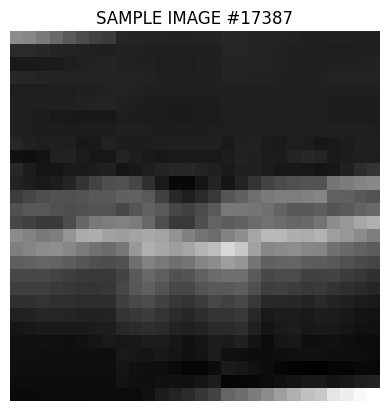

In [74]:
# import dataset

import numpy as np
import random
import matplotlib.pyplot as plt

# looking at file structure
data = np.load("octmnist.npz")

print("DATA KEYS:")
print(data.files)

X = data["train_images"]
y = data["train_labels"]

print("\nTRAINING DATA SIZE:")
print(X.shape)
print("\nIMAGE SIZE:")
print(X[0].shape)

# sample display image (random)
rand_sample = random.randint(0, 97476)
plt.imshow(X[rand_sample], cmap="gray")
plt.title("SAMPLE IMAGE #"+str(rand_sample))
plt.axis("off")
plt.show()


(97477, 784)


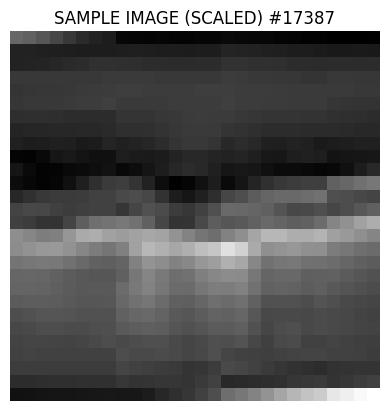

In [75]:
# fit scaler to training set

from sklearn.preprocessing import StandardScaler

X_flat = X.reshape(X.shape[0], -1) # PCA expects 2 dimensions: sample x feature
print(X_flat.shape)

# mean center the data (X_c = X - mu)
scaler = StandardScaler(with_std=False) # std scaling unnecessary for pixels
X_c = scaler.fit_transform(X_flat)

# display whatever sample (scaled) we already displayed above, for reference
plt.imshow(X_c[rand_sample].reshape(28, 28), cmap="gray")
plt.title("SAMPLE IMAGE (SCALED) #"+str(rand_sample))
plt.axis("off")
plt.show()


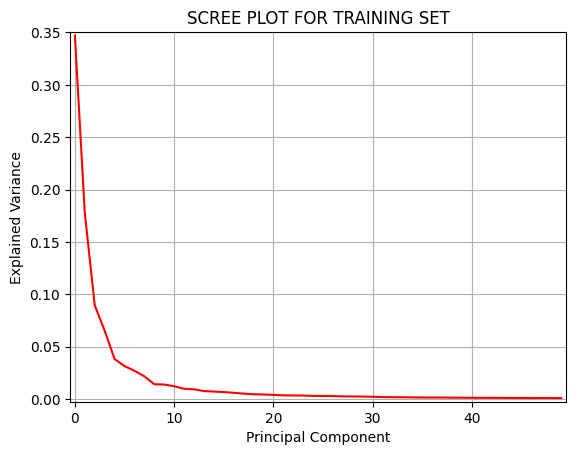

In [79]:
# fit PCA to training set and examine components

from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit(X_c) # fit the pca object to the data to retrieve all components (stored in the pca object)

# display the scree (we want to see the elbow)

components = pca.explained_variance_ratio_

plt.plot(range(50), components[:50], color="red")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.title("SCREE PLOT FOR TRAINING SET")
plt.margins(0.01)
plt.grid(True)
plt.show()

In [ ]:
# chosen k after examining scree

k_list = [3, 10, 20, 50, 100, 784] # 784 is the total number of principal components (28 x 28)
for k in k_list:
    print("CUMULATIVE VARIANCE (%) FOR k = {}:".format(k), components[:k-1].sum())

CUMULATIVE VARIANCE (%) FOR k = 3: 0.5241490639656564
CUMULATIVE VARIANCE (%) FOR k = 10: 0.8119283862726543
CUMULATIVE VARIANCE (%) FOR k = 20: 0.8951254988925984
CUMULATIVE VARIANCE (%) FOR k = 50: 0.9583810575316106
CUMULATIVE VARIANCE (%) FOR k = 100: 0.9833862634495495
CUMULATIVE VARIANCE (%) FOR k = 784: 0.9999999798554181


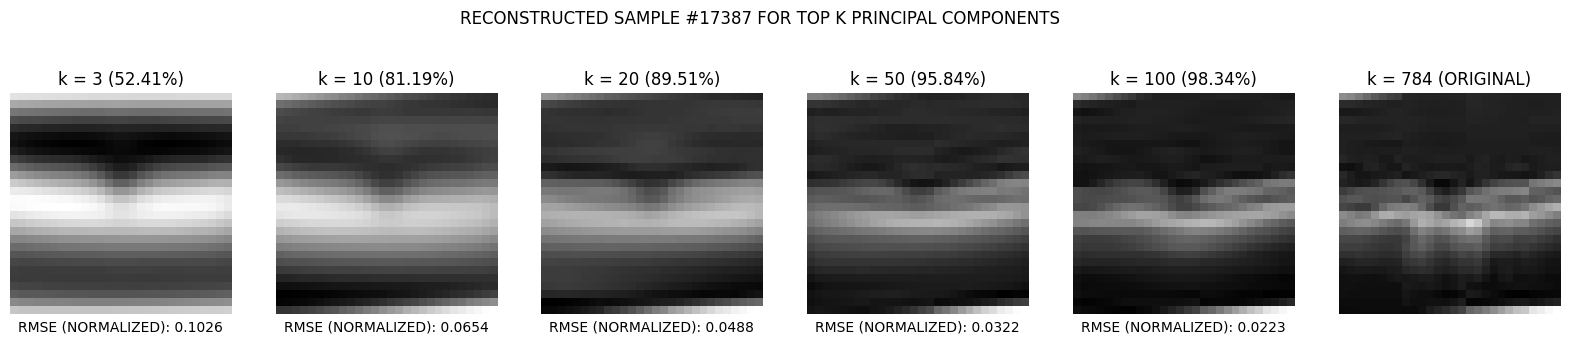

In [78]:
# reconstruct from k components

Z = pca.transform(X_c) # transform with full components first

fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(20, 4))
fig.suptitle("RECONSTRUCTED SAMPLE #{} FOR TOP K PRINCIPAL COMPONENTS".format(rand_sample))

for k, ax in zip(k_list, axes.flatten()):
    Z_k = np.copy(Z) 
    Z_k[:, k:] = 0 # remove all components after k in transformed matrix

    X_recon = pca.inverse_transform(Z_k) # reconstruct (remember it will return flattened)
    X_recon += scaler.mean_ # add the mean back in

    # compute mean squared error for reference (PCA guarantees minimization)
    rmse = np.sqrt(np.mean((X_flat[rand_sample] - X_recon[rand_sample])**2)) # in pixel intensity [0-255]
    rmse_norm = rmse / 255.0 # now [0, 1]

    # now we resize and plot the image
    ax.axis("off")
    if k == 784:
        ax.set_title("k = 784 (ORIGINAL)") # there are only 784 principal components (28*28)
    else:
        ax.set_title("k = {} ({:.2f}%)".format(k, components[:k-1].sum()*100))
        ax.text(0.5, 30, "RMSE (NORMALIZED): {:.4f}".format(rmse_norm), verticalalignment="bottom")

    ax.imshow(X_recon[rand_sample].reshape(28, 28), cmap="gray")

